<a href="https://colab.research.google.com/github/B-lr/price_prediction/blob/main/house_price2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
%matplotlib inline
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [ ]:
df_train = pd.read_csv('/content/train.csv')#Importing train.csv

df_test = pd.read_csv('/content/test.csv') #Importing test.csv

print("Shape of training data:", df_train.shape)
print("Shape of test data:", df_test.shape)


Shape of training data: (1460, 81)
Shape of test data: (1459, 80)


In [ ]:
df_train.head() #Displaying the table train data


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df_test.head() #Displaying the table test data


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [ ]:
data = df_train.append(df_test,sort=False) #Make train set and test set in the same data set
data.shape

<ipython-input-206-8df9b0f0cdbc>:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = df_train.append(df_test,sort=False) #Make train set and test set in the same data set


(2919, 81)

In [ ]:
# get the first 100 rows of train_df
data_100 = data.head(100)

# write the train_df_first_100 DataFrame to an Excel file
with pd.ExcelWriter('data_100.xlsx') as writer:
    data_100.to_excel(writer, index=False, sheet_name='Sheet1')

Data Quality checks


In [ ]:
#check for duplicates
duplicates = data.duplicated()
if duplicates.any():
    print(f"{duplicates.sum()} duplicates found:")
    print(data[duplicates])
else:
    print("No duplicates found.")

No duplicates found.


In [ ]:
#check for missing values
def get_cols_with_missing_values(df):
    missing_na_columns=(df.isnull().sum())
    return missing_na_columns[missing_na_columns > 0] #columns with more than 1 missing variables
print(get_cols_with_missing_values(data).sort_values(ascending=False))


PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
SalePrice       1459
FireplaceQu     1420
LotFrontage      486
GarageCond       159
GarageYrBlt      159
GarageFinish     159
GarageQual       159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrType        24
MasVnrArea        23
MSZoning           4
Functional         2
BsmtHalfBath       2
BsmtFullBath       2
Utilities          2
KitchenQual        1
TotalBsmtSF        1
BsmtUnfSF          1
GarageCars         1
GarageArea         1
BsmtFinSF2         1
BsmtFinSF1         1
Exterior2nd        1
Exterior1st        1
SaleType           1
Electrical         1
dtype: int64


In [ ]:
#print the contents of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2919 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [ ]:
#feature engineering on a dataset

numerical_features = [col for col in data.columns if data[col].dtype in ['float64', 'int64']] #creates a list of all columns in the dataset that have a numerical data type
discrete_features = [col for col in numerical_features if data[col].nunique() < 25 and col != 'Id']
continuous_features = [col for col in numerical_features if col not in discrete_features and col != 'Id']
categorical_features = [col for col in data.columns if data[col].dtype == 'object']#his line creates a list of all columns in the dataset that have an object data type.
print("Total Number of Numerical Columns : ",len(numerical_features))
print("Number of discrete features : ",len(discrete_features))
print("No of continuous features are : ", len(continuous_features))
print("Number of categorical features : ",len(categorical_features))

Total Number of Numerical Columns :  38
Number of discrete features :  15
No of continuous features are :  22
Number of categorical features :  43


In [ ]:
#fixing missing values
df1 = data.drop(['Alley','PoolQC','Fence','MiscFeature'],axis=1)#droping top misisng variables
df1.shape

(2919, 77)

In [ ]:
print(numerical_features)

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [ ]:
#fixing missing values in numerical features
df_num_miss = df1[numerical_features]

def get_cols_with_missing_values(df):
    missing_na_columns=(df.isnull().sum())
    return missing_na_columns[missing_na_columns > 0]
print(get_cols_with_missing_values(df_num_miss).sort_values(ascending=False))

SalePrice       1459
LotFrontage      486
GarageYrBlt      159
MasVnrArea        23
BsmtFullBath       2
BsmtHalfBath       2
BsmtFinSF1         1
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
GarageCars         1
GarageArea         1
dtype: int64


In [ ]:
#missing value transformations
#transformation into medians
df1['LotFrontage'] = df1.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
df1['GarageYrBlt'] = df1['GarageYrBlt'].fillna(df1['GarageYrBlt'].median())
df1['MasVnrArea'] = df1['MasVnrArea'].fillna(0)
df1['BsmtFullBath']=df1['BsmtFullBath'].fillna(0)
df1['BsmtHalfBath']=df1['BsmtHalfBath'].fillna(0)
df1['BsmtUnfSF']=df1['BsmtUnfSF'].fillna(0)
df1['BsmtFinSF2']=df1['BsmtFinSF2'].fillna(0)
df1['BsmtFinSF1']=df1['BsmtFinSF1'].fillna(0)
df1['GarageCars']=df1['GarageCars'].fillna(0)
df1['GarageArea']=df1['GarageArea'].fillna(0)
df1['TotalBsmtSF'] = df1['TotalBsmtSF'].fillna(df1['TotalBsmtSF'].mean())



In [ ]:
#missing value fixing of discrete_features
print(discrete_features)
df_dicrete_miss = df1[discrete_features]

def get_cols_with_missing_values(df):
    missing_na_columns=(df.isnull().sum())
    return missing_na_columns[missing_na_columns > 0]
print(get_cols_with_missing_values(df_dicrete_miss).sort_values(ascending=False))

['MSSubClass', 'OverallQual', 'OverallCond', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'PoolArea', 'MoSold', 'YrSold']
Series([], dtype: int64)


In [ ]:
#missing value fixing of discrete_features continuous_features
print(continuous_features)
df_cont_miss = df1[continuous_features]

def get_cols_with_missing_values(df):
    missing_na_columns=(df.isnull().sum())
    return missing_na_columns[missing_na_columns > 0]
print(get_cols_with_missing_values(df_cont_miss).sort_values(ascending=False))

['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageYrBlt', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MiscVal', 'SalePrice']
SalePrice    1459
dtype: int64


In [ ]:
#missing value fixing of categorical_features
print(categorical_features)
# Define the values to be removed
to_remove = ['Alley','PoolQC','Fence','MiscFeature']

# Use a list comprehension to remove the values
my_list = [x for x in categorical_features if x not in to_remove]
df_cat_miss = df1[my_list]

def get_cols_with_missing_values(df):
    missing_na_columns=(df.isnull().sum())
    return missing_na_columns[missing_na_columns > 0]
print(get_cols_with_missing_values(df_cat_miss).sort_values(ascending=False))


['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
FireplaceQu     1420
GarageCond       159
GarageQual       159
GarageFinish     159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrType        24
MSZoning           4
Functional         2
Utilities          2
KitchenQual        1
Electrical         1
Exterior2nd        1
Exterior1st        1
SaleType           1
dtype: int64


In [ ]:
#since precentage of missing values are less conveting them to

df1[my_list] = df1[my_list].fillna('NA')



In [ ]:
#confirming there are no missing values
def get_cols_with_missing_values(df):
    missing_na_columns=(df.isnull().sum())
    return missing_na_columns[missing_na_columns > 0]
print(get_cols_with_missing_values(df1).sort_values(ascending=False))

SalePrice    1459
dtype: int64


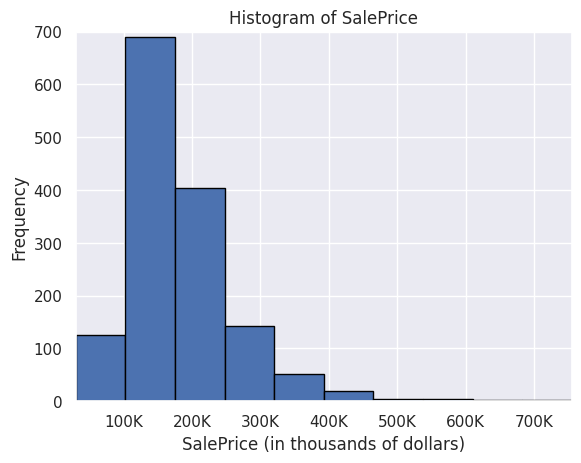

In [ ]:
#finding the distribution of Saleprice

from matplotlib.ticker import FuncFormatter
#train_df1['SalePrice'].hist()
plt.hist(df1['SalePrice'], edgecolor='black',range=[30000, 755000])

# set the x-axis and y-axis limits
plt.xlim(30000, 755000)
plt.ylim(0, 700)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:,.0f}K'.format(x/1000)))

# set the title and labels of the plot
plt.title('Histogram of SalePrice')
plt.xlabel('SalePrice (in thousands of dollars)')
plt.ylabel('Frequency')

# show the plot
plt.show()


<ipython-input-224-e1757864ea39>:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corrmat = df_train.corr()


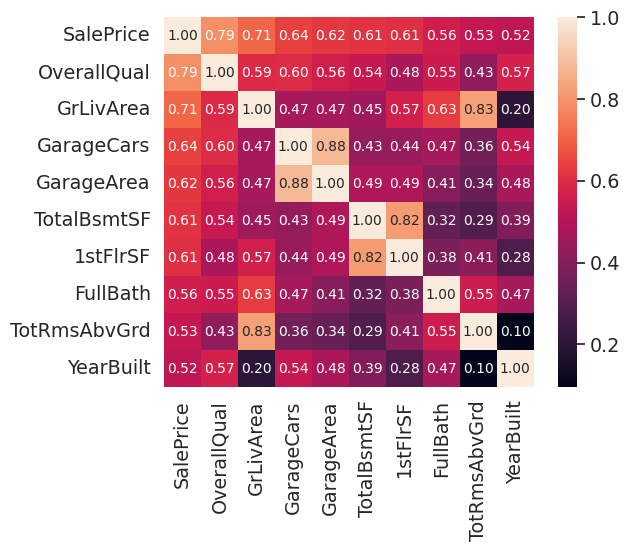

In [ ]:
#saleprice correlation matrix to find the highly correlated variables
k = 10 #number of variables for heatmap
corrmat = df_train.corr()
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df_train[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

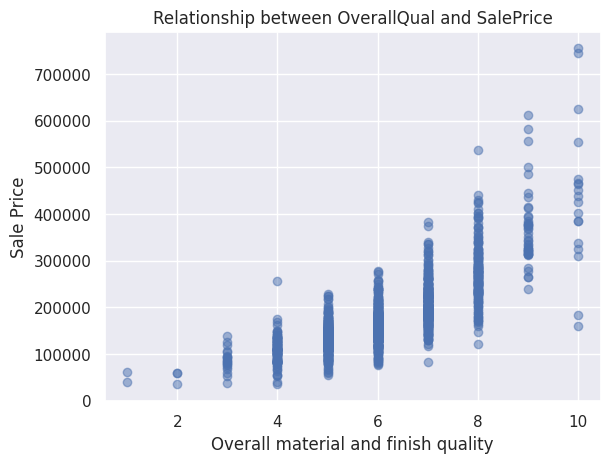

In [ ]:
#relation between SalePrice and OverallQual
plt.scatter(df1['OverallQual'], df1['SalePrice'], alpha=0.5)

# set axis labels and title
plt.xlabel('Overall material and finish quality')
plt.ylabel('Sale Price')
plt.title('Relationship between OverallQual and SalePrice')

plt.show()

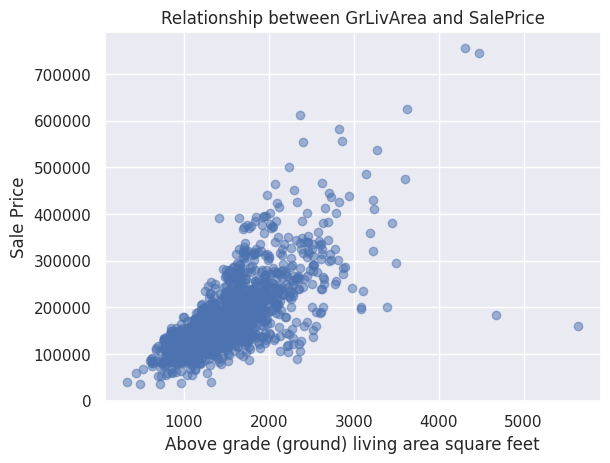

In [ ]:
# create a scatter plot between SalePrice and GrLivArea
plt.scatter(df1['GrLivArea'], df1['SalePrice'], alpha=0.5)

# set axis labels and title
plt.xlabel('Above grade (ground) living area square feet')
plt.ylabel('Sale Price')
plt.title('Relationship between GrLivArea and SalePrice')

plt.show()

In [ ]:
#removing ouliers
# sort the dataset by GrLivArea in descending order and select the top 4 rows
rows_to_drop = df1.sort_values(by='GrLivArea', ascending=False)[:4].index

# drop the rows from the dataset
df1.drop(rows_to_drop, inplace=True)

Text(0.5, 1.0, 'Relationship between YearBuilt and SalePrice')

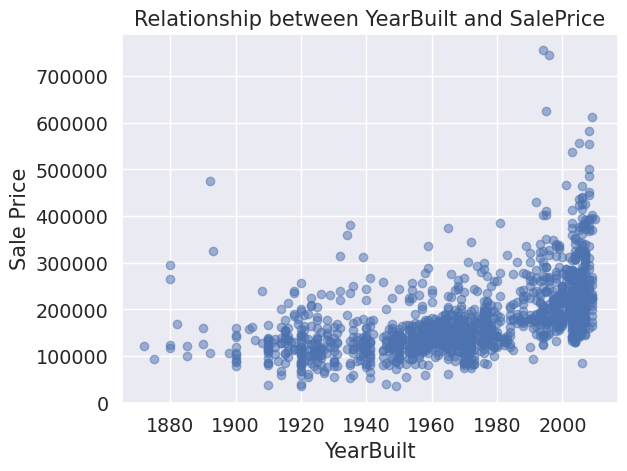

In [ ]:
# create a scatter plot of SalePrice vs. YearBuilt
plt.scatter(df1['YearBuilt'], df1['SalePrice'], alpha=0.5)

# set axis labels and title
plt.xlabel('YearBuilt')
plt.ylabel('Sale Price')
plt.title('Relationship between YearBuilt and SalePrice')

In [ ]:
#restricting the data to 1990<year< 2010

df1 = df1[(df1['YearBuilt'] >= 1900) & (df1['YearBuilt'] <= 2010)]

In [ ]:
df1.to_csv('/content/df1.csv', index=False)# just created to experiment with differeny models on another workbook

In [ ]:
# convert categorical variables to dummy variables and reset index
df2 = pd.get_dummies(df1).reset_index(drop=True)
df2.shape


(2893, 296)

In [ ]:
import numpy as np
# split predictor variables and dependent variable into separate variables
X = df2.drop(["SalePrice"], axis = 1)
y = df2['SalePrice']


In [ ]:
y= y.fillna(0)

In [ ]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# print the shapes of the training and testing data
print(f'train data shape : {X_train.shape}')
print(f'test data shape : {X_test.shape}')
print(f'trainy data shape : {y_train.shape}')
print(f'testy data shape : {y_test.shape}')


train data shape : (2025, 295)
test data shape : (868, 295)
trainy data shape : (2025,)
testy data shape : (868,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


# train a random forest regressor on the training data
regressor = RandomForestRegressor()
regressor.fit(X_train,y_train)
# generate predictions using the testing data
pred_y = regressor.predict(X_test)
# calculate the R2 score between the predicted and actual values
print(f"r2 Score : {r2_score(y_test, pred_y)}")

r2 Score : 0.9729150595531726


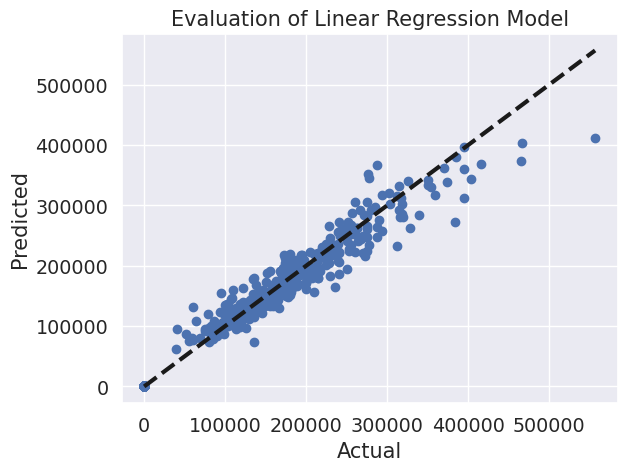

In [ ]:
import matplotlib.pyplot as plt
# plot predicted vs. actual values
plt.scatter(y_test, pred_y)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', lw=3)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Evaluation of Linear Regression Model')
plt.show()


In [ ]:
# Splitting the data to 80% trainging
n_train_rows = int(df2.shape[0]*.8)-1

# Split into train and test
train = df2.iloc[:n_train_rows, :]
test = df2.iloc[n_train_rows:, :]

# The total rows of the two datasets should equal the total amount of rows in your CSV
print(train.shape)
print(test.shape)


(2307, 295)
(578, 295)


In [ ]:
# Normalise features
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(train.values)
test_set_scaled = sc.fit_transform(test.values)

/usr/local/lib/python3.9/dist-packages/sklearn/preprocessing/_data.py:473: RuntimeWarning: All-NaN slice encountered
  data_min = np.nanmin(X, axis=0)
/usr/local/lib/python3.9/dist-packages/sklearn/preprocessing/_data.py:474: RuntimeWarning: All-NaN slice encountered
  data_max = np.nanmax(X, axis=0)


In [ ]:
#using sliding window

def sliding_window(data, look_back=1):
    x = []
    y = []

    for i in range(len(data)-look_back-1):
        a = data[i:(i+look_back), 0]
        x.append(a)
        y.append(data[i + look_back, 0])
    return np.array(x), np.array(y)



In [ ]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Activation
from keras.models import load_model
import tensorflow as tf

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import math
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

In [ ]:
# creating the input data and output data for training the model using a sliding window approach.

trainX, trainY = sliding_window(training_set_scaled, 3)
testX, testY = sliding_window(test_set_scaled, 3)

In [ ]:
from keras.callbacks import EarlyStopping
#model = Sequential()
epochs = 20
steps = 50
# Reshape input data for LSTM
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))
look_back =3
# Define LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(look_back, 1)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

#model.fit(x_train, y_train, batch_size = 32, epochs = epochs)
model.summary

model.save('my_model.h5')
history = model.fit(trainX, trainY, epochs=20, batch_size =4, validation_data=(testX, testY),
                    callbacks=[EarlyStopping(monitor='val_loss', patience=5)], verbose=1, shuffle=False)

Epoch 1/20
576/576 [==============================] - 5s 5ms/step - loss: 1.5616e-06 - val_loss: 0.0366
Epoch 2/20
576/576 [==============================] - 3s 5ms/step - loss: 8.2127e-04 - val_loss: 0.0055
Epoch 3/20
576/576 [==============================] - 4s 7ms/step - loss: 2.1433e-04 - val_loss: 9.6476e-04
Epoch 4/20
576/576 [==============================] - 2s 4ms/step - loss: 5.9080e-05 - val_loss: 6.8618e-05
Epoch 5/20
576/576 [==============================] - 2s 4ms/step - loss: 1.0822e-05 - val_loss: 2.6462e-05
Epoch 6/20
576/576 [==============================] - 2s 4ms/step - loss: 2.2348e-06 - val_loss: 4.3108e-05
Epoch 7/20
576/576 [==============================] - 3s 4ms/step - loss: 9.5457e-07 - val_loss: 7.7955e-05
Epoch 8/20
576/576 [==============================] - 3s 6ms/step - loss: 6.7291e-07 - val_loss: 1.8888e-05
Epoch 9/20
576/576 [==============================] - 2s 4ms/step - loss: 1.7726e-06 - val_loss: 1.2143e-05
Epoch 10/20
576/576 [===============

In [ ]:
y_pred = model.predict(testX)


18/18 [==============================] - 1s 2ms/step


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

#Evaluating the model using score
mse = mean_squared_error(testY, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.0045268817600401775


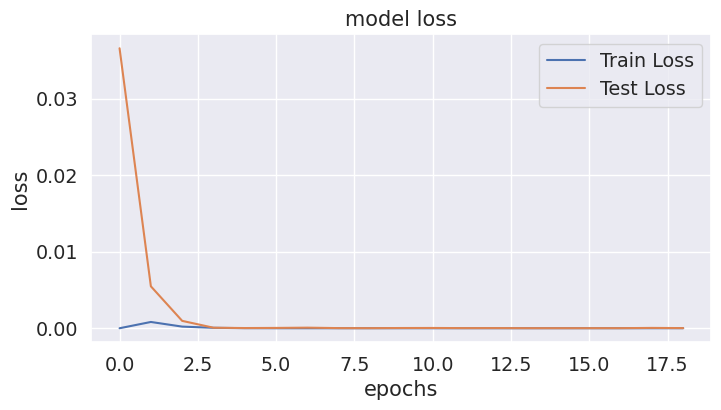

In [ ]:
#plot of the training loss and validation loss over the epochs of the model.
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(loc='upper right')
plt.show();